In [1]:
import os
import ndjson
import numpy as np
import struct
from struct import unpack
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
def image_grid(imgs, rows, cols):
    """
    Concatenates multiple images
    """
    assert len(imgs) == rows * cols

    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))


    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

def draw_strokes(strokes, height=256, width=256):
    """
    Make a new PIL image with the given strokes
    """
    image = Image.new("RGB", (width, height), "white")
    image_draw = ImageDraw.Draw(image)

    for stroke in strokes:
        # concat x and y coordinates
        points = list(zip(stroke[0], stroke[1]))

        # draw all points
        # image_draw.point(points, fill=0)
        image_draw.line(points, fill=0)

    return image

In [3]:
import os
import shutil

# ------------- class ------------ #
category = "apple"
data_path = f"./data/quickdraw/{category}.ndjson"
# -------------------------------- #

with open(data_path, 'r') as f:
    data = ndjson.load(f)
    
dic = {}
cnt = 0
stroke_cnt = 0
for i in data: 
    if i['recognized'] is True:
        # QuickDraw 데이터는 불균등한 형태이므로 직접 numpy 배열로 변환하지 않고 리스트로 저장
        drawing = i['drawing']
        stroke_cnt += len(drawing)

        
        dic[str(cnt)] = drawing  # 리스트 형태로 저장
        cnt += 1
        if cnt >= 70000:
            break

dic_item = list(dic.items())[:50]
print(stroke_cnt)

190347


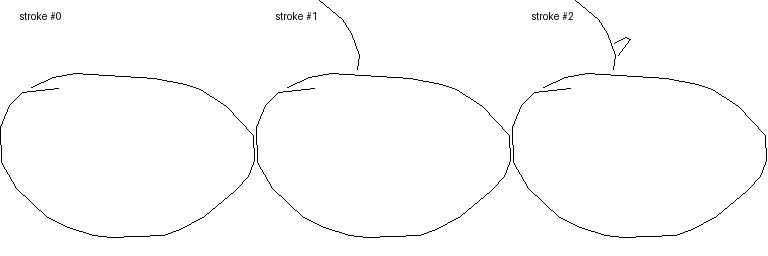

In [9]:
idx = -1

# full sequence of strokes
item = dic_item[idx][1:][0]
strokes = item

# sequence of strokes up to the current stroke
images = []
for i in range(len(strokes)):
    image = draw_strokes(strokes[:i+1])

    # add stroke number
    draw = ImageDraw.Draw(image)
    draw.text((20, 10), text=f"stroke #{i}", fill="black")
    images.append(image)

images_concat = image_grid(images, 1, len(images))
images_concat

In [25]:
dic_item[-2][1:][0]

[[[93,
   99,
   139,
   165,
   187,
   201,
   214,
   215,
   204,
   190,
   182,
   144,
   107,
   78,
   58,
   39,
   10,
   3,
   0,
   5,
   15,
   32,
   54,
   91,
   111,
   128,
   143,
   146,
   158,
   196,
   241,
   215,
   214,
   202,
   184,
   175,
   174,
   178,
   196,
   220],
  [133,
   124,
   87,
   80,
   84,
   90,
   112,
   140,
   194,
   212,
   219,
   226,
   248,
   255,
   251,
   241,
   183,
   159,
   127,
   106,
   87,
   74,
   65,
   62,
   66,
   76,
   97,
   71,
   42,
   16,
   0,
   26,
   37,
   54,
   65,
   76,
   93,
   102,
   113,
   119]]]

In [5]:
import numpy as np
import os
import shutil
import ndjson
from sklearn.cluster import KMeans
import random

categorys = ['apple']
output_filename = f'sketches_apple.npz'
dictionary_path = f'dictionary_apple.npy'
output_dir = '/home/hyunseo/workspace/KAIST-2025-S/discrete_model_testbed/data/full_sketch'
each_sample_size = 4000
total_sample_size = each_sample_size * len(categorys)

K = 256
MAX_LEN = 45

PAD_TOKEN = 0
SEP_TOKEN = 1
num_special_token = 2

def get_all_offsets(dic_item):
    all_offsets = []
    for i, sketch_data in enumerate(dic_item):
        sketch = sketch_data[1]
        last_x, last_y = 0, 0
        for stroke in sketch:
            points = list(zip(stroke[0], stroke[1]))
            for x, y in points:
                dx = x - last_x
                dy = y - last_y
                all_offsets.append([dx, dy])
                last_x, last_y = x, y
    return np.array(all_offsets)

def create_dictionary(offsets, k, sample_size):
    sample_indices = random.sample(range(len(offsets)), min(sample_size, len(offsets)))
    samples = offsets[sample_indices]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(samples)
    dictionary = kmeans.cluster_centers_
    return dictionary

sketch_dict = {}
cnt = 0
for category in categorys:
    data_path = f"./data/quickdraw/{category}.ndjson"

    with open(data_path, 'r') as f:
        data = ndjson.load(f)
    category_count = 0
    for item in data:
        if item.get('recognized') is True:
            drawing = item.get('drawing', [])
            
            num_points = sum(len(stroke[0]) for stroke in drawing)
            
            if num_points > 0 and num_points <= MAX_LEN:
                sketch_dict[str(cnt)] = drawing
                cnt += 1
                category_count += 1

                if category_count >= each_sample_size:
                    break
            

sketch_items = list(sketch_dict.items())
print(f"Loaded {len(sketch_items)} recognized sketches.")

all_offsets = get_all_offsets(sketch_items)
dictionary = create_dictionary(all_offsets, K, total_sample_size)
np.save(dictionary_path, dictionary)
print(f"Dictionary with {len(dictionary)} codewords saved to '{dictionary_path}'.")

print("\n--- 3. Tokenizing sketches ---")
all_tokenized_sketches = []


for i, (key, sketch) in enumerate(sketch_items):
    if (i + 1) % 1000 == 0:
        print(f"Processing sketch {i+1}/{len(sketch_items)}...")

    token_sequence = []
    pen_state_sequence = []
    
    last_x, last_y = 0, 0
    # 획(stroke) 단위로 처리
    for stroke_idx, stroke in enumerate(sketch):
        points = list(zip(stroke[0], stroke[1]))
        
        for point_idx, (x, y) in enumerate(points):
            dx = x - last_x
            dy = y - last_y
            
            offset = np.array([dx, dy])
            distances = np.linalg.norm(dictionary - offset, axis=1)
            codeword_id = np.argmin(distances)
            
            token_sequence.append(codeword_id + num_special_token)
            last_x, last_y = x, y

            if point_idx == len(points) - 1 and stroke_idx < len(sketch) - 1:
                token_sequence.append(SEP_TOKEN)  # separator (1)


    current_len = len(token_sequence)
    if current_len > MAX_LEN:
        token_sequence = token_sequence[:MAX_LEN]
    if current_len < MAX_LEN:
        pad_len = MAX_LEN - current_len
        token_sequence.extend([PAD_TOKEN] * pad_len)
    
    token_sequence = np.array(token_sequence)
    all_tokenized_sketches.append(token_sequence)


final_sketches = np.array(all_tokenized_sketches, dtype=np.int32)
print(f"Final combined data shape: {final_sketches.shape}")

sketch_dict_to_save = {f'{i}': seq for i, seq in enumerate(final_sketches)}
np.savez_compressed(output_filename, **sketch_dict_to_save)

loaded_data = np.load(output_filename)
print(f"Saved file keys: {loaded_data.files[:10]}...")
print(f"Example tokenized sketch (first 5 tokens with pen states):\n{loaded_data['0'][:5]}")

vocab_size = K + num_special_token
print(f"Final vocabulary size: {vocab_size}")

os.makedirs(output_dir, exist_ok=True)
if os.path.exists(os.path.join(output_dir, output_filename)):
    os.remove(os.path.join(output_dir, output_filename))
shutil.move(output_filename, output_dir)


if os.path.exists(os.path.join(output_dir, dictionary_path)):
    os.remove(os.path.join(output_dir, dictionary_path))
shutil.move(dictionary_path, output_dir)
print(f"Files moved to '{output_dir}'.")


Loaded 4000 recognized sketches.
Dictionary with 256 codewords saved to 'dictionary_apple.npy'.

--- 3. Tokenizing sketches ---
Processing sketch 1000/4000...
Processing sketch 2000/4000...
Processing sketch 3000/4000...
Processing sketch 4000/4000...
Final combined data shape: (4000, 45)
Saved file keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
Example tokenized sketch (first 5 tokens with pen states):
[ 53  61 172  66 187]
Final vocabulary size: 258
Files moved to '/home/hyunseo/workspace/KAIST-2025-S/discrete_model_testbed/data/full_sketch'.


총 400개의 스케치를 로드했습니다.


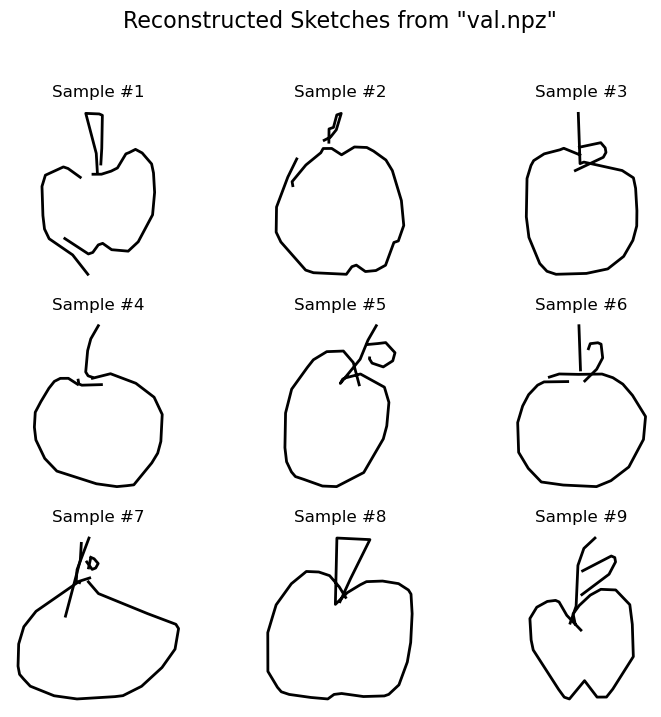

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# --- 설정 (Configuration) ---
# 원본 코드에서 생성된 파일 경로를 지정합니다.
DATA_DIR = '/home/hyunseo/workspace/KAIST-2025-S/discrete_model_testbed/data/full_sketch'
NPZ_FILENAME = 'val.npz'
# NPZ_FILENAME = 'samples_batch_0.npz'

DICTIONARY_FILENAME = 'dictionary_apple.npy'

# 시각화할 스케치의 개수를 지정합니다.
NUM_TO_VISUALIZE = 9

# 원본 코드와 동일한 상수 값을 사용해야 합니다.
K = 256
PAD_TOKEN = 0
SEP_TOKEN = 1
NUM_SPECIAL_TOKEN = 2
# --- 설정 끝 ---

def visualize_sketch_from_tokens(token_sequence, dictionary, ax):
    """
    하나의 토큰 시퀀스와 사전을 받아 스케치를 복원하고 그립니다.
    SEP_TOKEN을 만나면, 다음 토큰의 오프셋만큼 이동하고 그리기 시작합니다.
    """
    codeword_id = token_sequence[0] - NUM_SPECIAL_TOKEN
    last_x, last_y = dictionary[codeword_id]
    current_stroke = [(last_x, last_y)]
    
    i = 1
    while i < len(token_sequence):
        token = token_sequence[i]
        if token == PAD_TOKEN:
            break

        if token == SEP_TOKEN:
            if len(current_stroke) > 1:
                xs, ys = zip(*current_stroke)
                ax.plot(xs, ys, color='black', linewidth=2)
            
            i += 1
            if i >= len(token_sequence) or token_sequence[i] == PAD_TOKEN:
                break # 이동할 토큰이 없으면 종료

            move_token = token_sequence[i]
            codeword_id = move_token - NUM_SPECIAL_TOKEN
            
            if 0 <= codeword_id < len(dictionary):
                dx, dy = dictionary[codeword_id]
                last_x += dx
                last_y += dy
            
            current_stroke = [(last_x, last_y)]
            
            i += 1
            continue

        # 일반 토큰인 경우, 점을 추가합니다.
        codeword_id = token - NUM_SPECIAL_TOKEN
        if 0 <= codeword_id < len(dictionary):
            dx, dy = dictionary[codeword_id]
            new_x, new_y = last_x + dx, last_y + dy
            current_stroke.append((new_x, new_y))
            last_x, last_y = new_x, new_y
        
        i += 1

    # 루프 종료 후 마지막 획을 그립니다.
    if len(current_stroke) > 1:
        xs, ys = zip(*current_stroke)
        ax.plot(xs, ys, color='black', linewidth=2)

    # 보기 좋게 축과 비율을 조정합니다.
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()  # QuickDraw 데이터는 y축이 아래로 향합니다.
    ax.axis('off')


# --- 메인 실행 로직 ---
if __name__ == "__main__":
    # 1. 데이터 로드
    npz_file_path = os.path.join(DATA_DIR, NPZ_FILENAME)
    dictionary_path = os.path.join(DATA_DIR, DICTIONARY_FILENAME)

    try:
        token_data = np.load(npz_file_path)
        dictionary = np.load(dictionary_path)
    except FileNotFoundError:
        print(f"오류: '{npz_file_path}' 또는 '{dictionary_path}' 파일을 찾을 수 없습니다.")
        print("먼저 데이터 처리 코드를 실행하여 파일을 생성했는지 확인해주세요.")
        exit()

    # .npz 파일에서 모든 토큰 시퀀스를 리스트로 변환
    all_token_sequences = [token_data[key] for key in token_data.files]
    print(f"총 {len(all_token_sequences)}개의 스케치를 로드했습니다.")

    # 2. 시각화할 스케치 랜덤 선택
    num_samples = min(NUM_TO_VISUALIZE, len(all_token_sequences))
    if num_samples == 0:
        print("시각화할 스케치가 없습니다.")
        exit()
        
    sketches_to_show = all_token_sequences[:num_samples]

    # 3. 플롯 생성 및 시각화
    cols = int(np.ceil(np.sqrt(num_samples)))
    rows = int(np.ceil(num_samples / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = axes.flatten() 

    for i, token_seq in enumerate(sketches_to_show):
        ax = axes[i]
        visualize_sketch_from_tokens(token_seq, dictionary, ax)
        ax.set_title(f"Sample #{i+1}")

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Reconstructed Sketches from "{NPZ_FILENAME}"', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()